# 01 — Potencial efectivo deformado

Exploración de $V_h(r;\omega,m)$ para la familia de perfiles deformados.

Objetivo: comprobar visualmente que (a) el horizonte no se mueve, (b) la barrera
de potencial sí cambia de altura/ancho/asimetría con $h$. Si (b) fallara, el
estudio de identificabilidad sería vacuo.

In [8]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA de PyTorch:", torch.version.cuda)

PyTorch: 2.9.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA de PyTorch: 12.8


In [3]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.physics.background import DrainingBathtub
from src.physics.deformation import NullDeformation, GaussianDeformation, PolynomialDeformation
from src.mathematics.potential import V_effective, g_metric

bg = DrainingBathtub(A=1.0, B=0.7, c=1.0)   # unidades: r_h = 1
print(f'r_h={bg.r_h:.4f}  r_e={bg.r_e:.4f}  Omega_H={bg.Omega_H:.4f}  kappa_h={bg.surface_gravity:.4f}')

r_h=1.0000  r_e=1.2207  Omega_H=0.7000  kappa_h=1.0000


## Perfiles deformados y función métrica

In [4]:
familia = {
    'h = 0':            NullDeformation(r_h=bg.r_h),
    'gauss e=+0.4':     GaussianDeformation(r_h=bg.r_h, eps=0.4, sigma=2.0),
    'gauss e=-0.3':     GaussianDeformation(r_h=bg.r_h, eps=-0.3, sigma=2.0),
    'poly a=(0.2,-0.1)': PolynomialDeformation(r_h=bg.r_h, a=[0.2, -0.1]),
}
for nombre, d in familia.items():
    d.check_boundary_conditions()
    print(f'{nombre:20s}  h(r_h)=0, h\'(r_h)=0  OK   g(r_h)={g_metric(bg.r_h, bg, d):.2e}')

h = 0                 h(r_h)=0, h'(r_h)=0  OK   g(r_h)=0.00e+00
gauss e=+0.4          h(r_h)=0, h'(r_h)=0  OK   g(r_h)=0.00e+00
gauss e=-0.3          h(r_h)=0, h'(r_h)=0  OK   g(r_h)=0.00e+00
poly a=(0.2,-0.1)     h(r_h)=0, h'(r_h)=0  OK   g(r_h)=0.00e+00


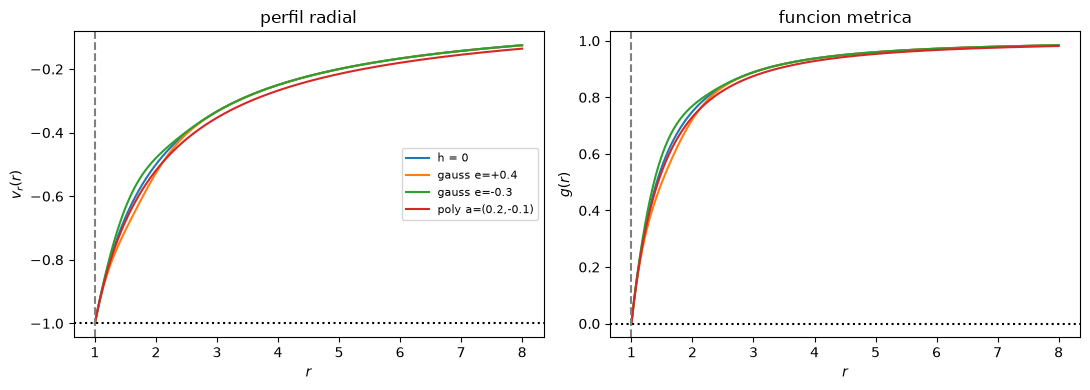

In [5]:
r = np.linspace(bg.r_h*1.001, 8.0, 800)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for nombre, d in familia.items():
    ax[0].plot(r, -(bg.A/r)*(1+d.h(r)), label=nombre)
    ax[1].plot(r, g_metric(r, bg, d), label=nombre)
ax[0].axhline(-bg.c, ls=':', c='k'); ax[0].axvline(bg.r_h, ls='--', c='grey')
ax[0].set_xlabel('$r$'); ax[0].set_ylabel('$v_r(r)$'); ax[0].set_title('perfil radial')
ax[1].axhline(0, ls=':', c='k'); ax[1].axvline(bg.r_h, ls='--', c='grey')
ax[1].set_xlabel('$r$'); ax[1].set_ylabel('$g(r)$'); ax[1].set_title('funcion metrica')
ax[0].legend(fontsize=8); plt.tight_layout()

## Barrera de potencial

$V_h$ depende de $\omega$: se fija un $\omega$ real de referencia dentro de la
banda superradiante para visualizar.

banda superradiante m=2: (0, 1.4000);  omega usado = 0.7000


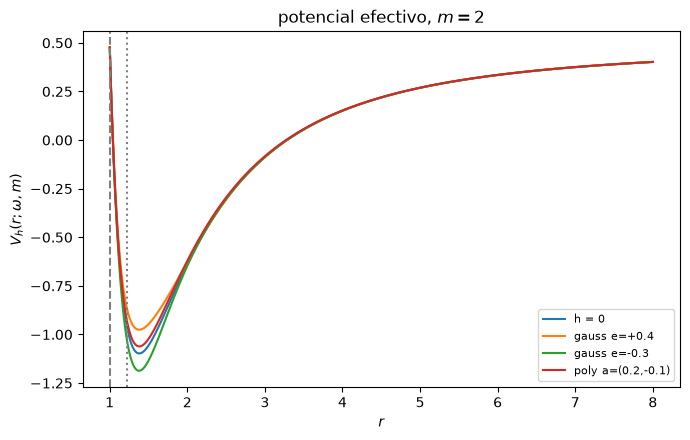

In [6]:
m = 2
w0, w1 = bg.superradiant_band(m)
omega = 0.5 * w1
print(f'banda superradiante m={m}: (0, {w1:.4f});  omega usado = {omega:.4f}')

plt.figure(figsize=(7, 4.5))
for nombre, d in familia.items():
    plt.plot(r, V_effective(r, omega, m, bg, d), label=nombre)
plt.axvline(bg.r_h, ls='--', c='grey'); plt.axvline(bg.r_e, ls=':', c='grey')
plt.xlabel('$r$'); plt.ylabel(r'$V_h(r;\omega,m)$')
plt.title(f'potencial efectivo, $m={m}$'); plt.legend(fontsize=8); plt.tight_layout()

## Sensibilidad

Precursor del análisis de Fisher: $\partial V_h/\partial\theta_j$ por diferencias
finitas. Direcciones con sensibilidad pequeña o casi paralelas anticipan
degeneraciones en la matriz de información.

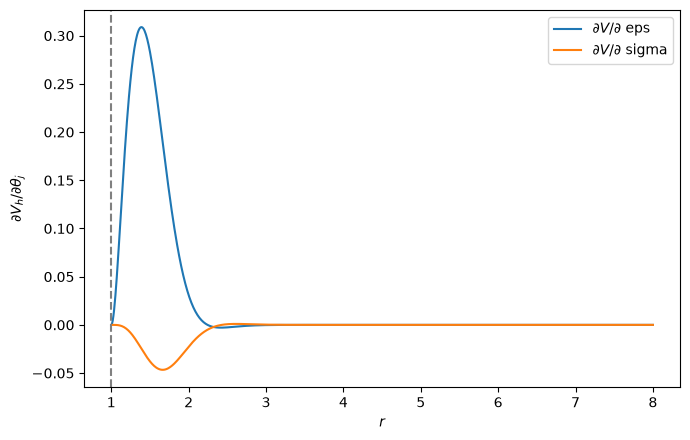

In [7]:
base = GaussianDeformation(r_h=bg.r_h, eps=0.4, sigma=2.0)
delta = 1e-5
plt.figure(figsize=(7, 4.5))
for j, nombre_p in enumerate(base.theta_names):
    th = base.theta.copy(); th[j] += delta
    up = GaussianDeformation(r_h=bg.r_h, eps=th[0], sigma=th[1])
    th = base.theta.copy(); th[j] -= delta
    dn = GaussianDeformation(r_h=bg.r_h, eps=th[0], sigma=th[1])
    dV = (V_effective(r, omega, m, bg, up) - V_effective(r, omega, m, bg, dn)) / (2*delta)
    plt.plot(r, dV, label=rf'$\partial V/\partial$ {nombre_p}')
plt.axvline(bg.r_h, ls='--', c='grey'); plt.xlabel('$r$')
plt.ylabel(r'$\partial V_h/\partial\theta_j$'); plt.legend(); plt.tight_layout()